In [1]:
import numpy as np
import importlib
import regulator
import matplotlib.pyplot as plt

In [2]:
!python --version

/bin/bash: line 1: python: command not found


In [3]:
from importlib import reload
import my_dataclasses
reload(my_dataclasses)
import my_dataclasses

In [4]:
import flowNLO
reload(flowNLO)
import flowNLO

from flowNLO import FlowNLO

In [28]:
N_p=100
p_min=0.01
p_max=100.
N_w=100
w_min=0.01
w_max=100.
params_grid_external=my_dataclasses.Params_grid_external(N_p=N_p, p_min=p_min, p_max=p_max,
                                                        N_w=N_w, w_min=w_min, w_max=w_max)

In [29]:
params_grid_internal=my_dataclasses.Params_grid_internal(deg_q=500, q_max=10)

In [30]:
approximation="LO"
dim=1
ds=0.02
f_in = np.ones((N_p,1))
IC = my_dataclasses.IC_NLO(g_in=1., eta_D_in=0., eta_nu_in=0., f_D_in=f_in, f_nu_in=f_in, f_lambda_in=f_in)
r  = lambda x : regulator.exp1(x, 1, 1)
r_ = lambda x : regulator.exp1_(x, 1, 1)

version_Ak="1"
path_save='test'
save_spl=False

s_fin=-0.1
n_print=1
n_save_params=2
n_save_f=2

In [31]:
s_fin/ds

-5.0

In [35]:
flow = FlowNLO(approximation=approximation,dim=dim,
            params_grid_external=params_grid_external,
            params_grid_internal=params_grid_internal,
            ds=ds, IC=IC,
            r=r,r_=r_, 
            version_Ak = version_Ak,
			path_save=path_save, save_spl=save_spl)

1D versions are used: theta = [0.         3.14159265] wtheta = [1 1]
1D: vdim1 = 1 Jdim1 = 1
1D: self.sin_d2_broad = 1
=== Initialized with the following parameters: ===
approximation=LO
dim=1
version_Ak=1
p_min=0.01
p_max=100.0
Np=100
Nw=1
q_max=10
degtheta=2
save_spl=False
ds=0.02


In [9]:
flow.f_spline_update() 

f_spline_update_LO


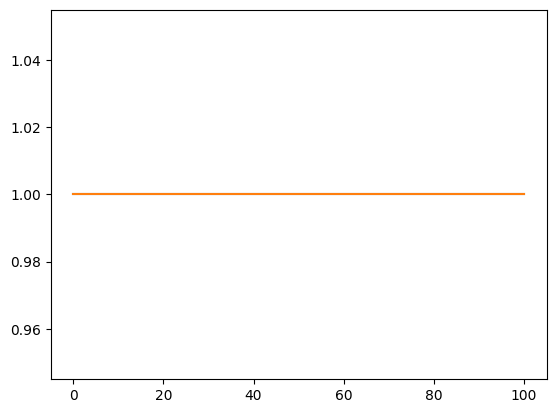

In [11]:
plt.plot(flow.p,flow.f_nu[:,0])
plt.plot(flow.p,flow.f_nu_spl[0](flow.p))

In [12]:
flow.Is_update() 

f_spline_update_LO


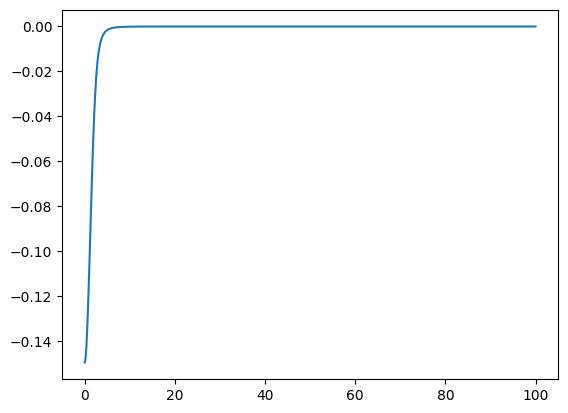

In [13]:
plt.plot(flow.p,flow.Is_D[:,0])

In [14]:
flow.eta_update() 

In [15]:
flow.eta_D,flow.eta_nu

(np.float64(0.14149934942004086), np.float64(0.14149934942004083))

In [16]:
flow.g

1.0

In [17]:
flow.g_update() 

In [18]:
flow.g

np.float64(1.0143400260231983)

In [19]:
flow.f_update() 

f_spline_update_LO


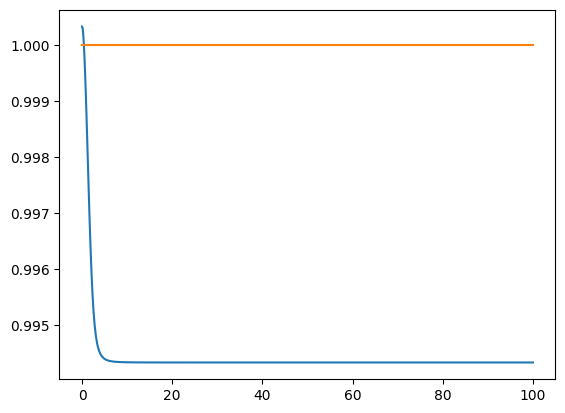

In [20]:
plt.plot(flow.p,flow.f_nu[:,0])
plt.plot(flow.p,flow.f_nu_spl[0](flow.p))

In [21]:
flow.f_spline_update() 

f_spline_update_LO


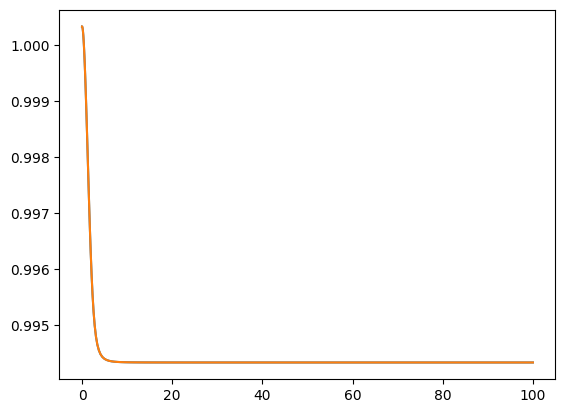

In [22]:
plt.plot(flow.p,flow.f_nu[:,0])
plt.plot(flow.p,flow.f_nu_spl[0](flow.p))

In [36]:
flow.RG_Evolution(s_fin, n_print, n_save_params, n_save_f)

START RG_Evolution
s 	 eta_D 	 eta_nu 	 g 	 -ID[0,0] 	 -Inu[0,0]
	0.000	0.14249	0.14139	1.014	0.15067	0.14948
	-0.020	0.14453	0.14326	1.029	0.14482	0.14344
	-0.040	0.14665	0.14518	1.043	0.14694	0.14537
	-0.060	0.14878	0.14712	1.058	0.14907	0.14731
	-0.080	0.15092	0.14907	1.073	0.15122	0.14926
FINISH Saved in test


In [5]:
approximation="LO"
version_Ak="1"
dim=1

path_save = 'LO_exp1_a8_b0,5_ds0,002'

alpha = 8
beta = 0.5
r  = lambda x : regulator.exp1(x, alpha, beta)
r_ = lambda x : regulator.exp1_(x, alpha, beta)

N_p, p_min, p_max = 100, 0.01, 100 
N_w, w_min, w_max = 1,0,0#Do not matter in LO, but need Nw=1 for IC
q_max, deg_q, degtheta = 4, 50, 2
params_grid_external=my_dataclasses.Params_grid_external(N_p=N_p, p_min=p_min, p_max=p_max,
                                                         N_w=N_w, w_min=w_min, w_max=w_max)
params_grid_internal=my_dataclasses.Params_grid_internal(deg_q, q_max)

s_fin = -20
ds = 0.002

g_in = 1.
eta_D, eta_nu = 0, 0
f_in = np.ones((N_p,1))
print(f_in)

IC = my_dataclasses.IC_NLO(g_in=1., eta_D_in=0., eta_nu_in=0., f_D_in=f_in, f_nu_in=f_in, f_lambda_in=f_in)

n_print = 40
n_save_params = 1
n_save_f = 40
save_spl=False

[[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]]


In [6]:
s_fin/ds/n_save_f

-250.0

In [7]:
flow = FlowNLO(approximation=approximation,dim=dim,
            params_grid_external=params_grid_external,
            params_grid_internal=params_grid_internal,
            ds=ds, IC=IC,
            r=r,r_=r_, 
            version_Ak = version_Ak,
			path_save=path_save, save_spl=save_spl)

1D versions are used: theta = [0.         3.14159265] wtheta = [1 1]
1D: vdim1 = 1 Jdim1 = 1
1D: self.sin_d2_broad = 1
=== Initialized with the following parameters: ===
approximation=LO
dim=1
version_Ak=1
p_min=0.01
p_max=100
Np=100
Nw=1
q_max=4
degtheta=2
save_spl=False
ds=0.002


In [8]:
flow.RG_Evolution(s_fin, n_print, n_save_params, n_save_f)

START RG_Evolution
s 	 eta_D 	 eta_nu 	 g 	 -ID[0,0] 	 -Inu[0,0]
	0.000	0.06433	0.06433	1.002	0.06560	0.06560
	-0.080	0.06889	0.06889	1.074	0.06889	0.06889
	-0.160	0.07372	0.07372	1.150	0.07372	0.07372
	-0.240	0.07881	0.07881	1.230	0.07882	0.07882
	-0.320	0.08418	0.08418	1.315	0.08419	0.08419
	-0.400	0.08983	0.08983	1.405	0.08983	0.08983
	-0.480	0.09576	0.09576	1.500	0.09576	0.09576
	-0.560	0.10197	0.10197	1.599	0.10198	0.10197
	-0.640	0.10846	0.10846	1.703	0.10847	0.10847
	-0.720	0.11524	0.11524	1.812	0.11525	0.11524
	-0.800	0.12229	0.12229	1.926	0.12230	0.12230
	-0.880	0.12961	0.12961	2.045	0.12962	0.12962
	-0.960	0.13720	0.13720	2.168	0.13721	0.13721
	-1.040	0.14504	0.14504	2.296	0.14505	0.14505
	-1.120	0.15312	0.15312	2.429	0.15313	0.15313
	-1.200	0.16143	0.16143	2.565	0.16144	0.16144
	-1.280	0.16995	0.16995	2.706	0.16997	0.16996
	-1.360	0.17867	0.17867	2.851	0.17868	0.17868
	-1.440	0.18756	0.18756	2.999	0.18757	0.18757
	-1.520	0.19660	0.19660	3.150	0.19661	0.19661
	-1.600	0.20576	

In [9]:

from importlib import reload
import my_plot_NLO
reload(my_plot_NLO)
import my_plot_NLO

In [10]:
f_nu = np.array(
    np.loadtxt(
    open(flow.path+'/f_nu.dat').readlines()#[:-1]
    )
)
print(f_nu.shape)
stepmax=f_nu.shape[0]
f_nu = np.reshape(f_nu, (stepmax, flow.Np, flow.Nw))

f_D = np.array(
    np.loadtxt(
    open(flow.path+'/f_D.dat').readlines()#[:-1]
    )
)
print(f_D.shape)
f_D = np.reshape(f_D, (stepmax, flow.Np, flow.Nw))

(251, 100)
(251, 100)


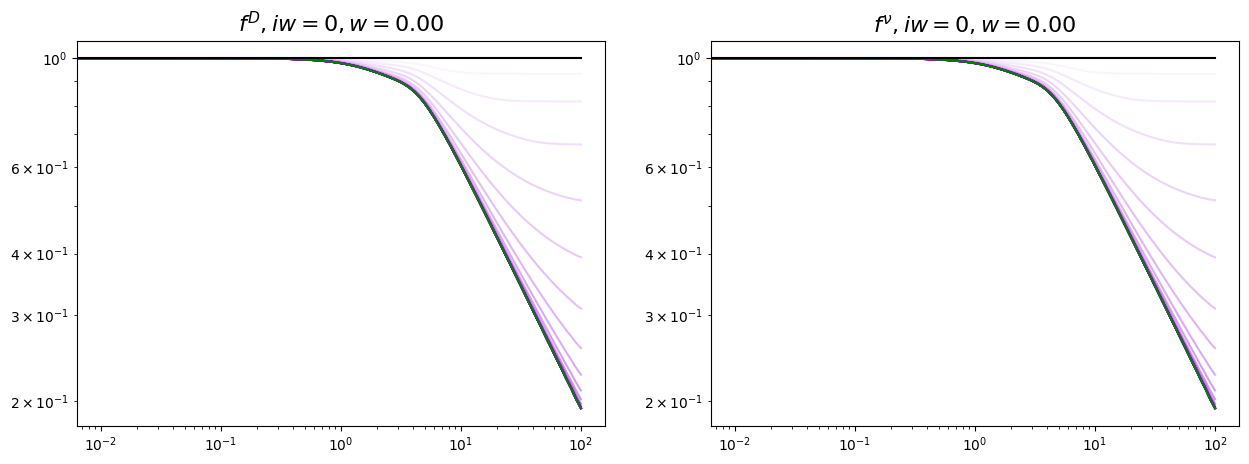

In [11]:
my_plot_NLO.fs_of_p_w0_fixed_alphas(f_D, f_nu, f_in, f_in, flow.p, flow.w, iw0=0, 
                                    s0=0,stepmax=stepmax,step=10,xscale='log', yscale='log')

In [13]:
par = np.loadtxt(
    open(path_save+'/flow_parameters.dat')#.readlines()[:-1] 
)
s = par[:,0]
eta_D_eff = par[:,1]
eta_nu_eff = par[:,2]
g_eff = par[:,3]

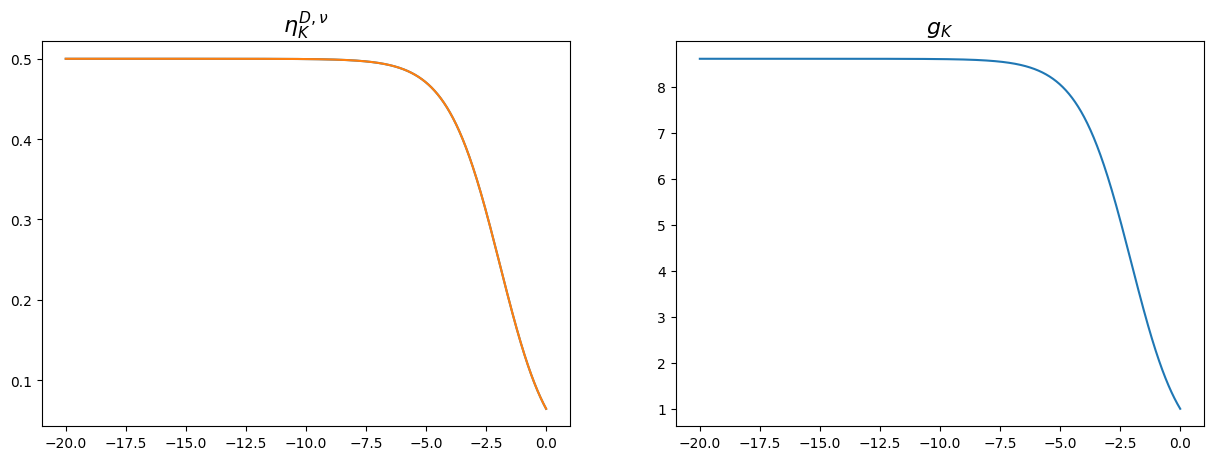

In [16]:
num=2
fig, ax = plt.subplots(1,num, figsize=(7.5*num, 5))

ax[0].set_title(r'$\eta^{D,\nu}_K$', fontsize=16)
ax[0].plot(s, eta_D_eff)
ax[0].plot(s, eta_nu_eff)

ax[1].set_title(r'$g_K$', fontsize=16)
ax[1].plot(s, g_eff)

plt.show()

In [17]:
g_eff[-1], g_eff[-2]

(np.float64(8.606373887433461), np.float64(8.606373886492099))